In [25]:
# =========================================================================
# PROJECT: Explainable Brain Tumor MRI Classification
# Subtitle: EfficientNetB0 Classification with Grad-CAM-Based
#           Misclassification Analysis
#
# Dataset: Brain Tumor MRI Dataset (Kaggle, 7,200 images, 4 classes)
# Classes: glioma, meningioma, pituitary, notumor
# =========================================================================

# =========================================================================
# CELL 1 — Imports
# =========================================================================
# What this does:
# Loads every library we need across the whole notebook in one place.
# tensorflow/keras -> building and training the CNN
# sklearn          -> confusion matrix, classification report
# cv2, matplotlib  -> image handling and visualization for Grad-CAM
# numpy            -> array math

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))



TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [52]:

# =========================================================================
# CELL 2 — Paths and constants
# =========================================================================
# What this does:
# Defines where your dataset lives and the fixed settings used everywhere
# else in the notebook. EDIT TRAIN_DIR and TEST_DIR to match your own
# folder location before running.
#
# IMG_SIZE = 224x224 because that's what EfficientNetB0 expects as input.
# BATCH = how many images the model looks at per training step.

from pathlib import Path

BASE_DIR = Path("..").resolve()
DATASET_DIR = BASE_DIR / "Dataset"
TRAIN_DIR = DATASET_DIR / "Training"
TEST_DIR = DATASET_DIR / "Testing"



# Output folder inside the project
OUTPUT_DIR = BASE_DIR / "outcome"
OUTPUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = (160, 160)
BATCH = 8
SEED = 42

print("Project:", BASE_DIR)
print("Training:", TRAIN_DIR)
print("Testing :", TEST_DIR)


Project: /mnt/d/1 Univesrity work/Lect 2/FOD/MRI-Based-Brain-Tumor-Classification-and-Explainability-Using-CNN-and-Transfer-Learning
Training: /mnt/d/1 Univesrity work/Lect 2/FOD/MRI-Based-Brain-Tumor-Classification-and-Explainability-Using-CNN-and-Transfer-Learning/Dataset/Training
Testing : /mnt/d/1 Univesrity work/Lect 2/FOD/MRI-Based-Brain-Tumor-Classification-and-Explainability-Using-CNN-and-Transfer-Learning/Dataset/Testing


In [53]:
# =========================================================================
# CELL 3 — Data loading (no manual rescaling — EfficientNetB0 handles its
# own preprocessing internally, expects raw 0-255 pixel values)
# =========================================================================

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="categorical", validation_split=0.15,
    subset="training", seed=SEED
)
val_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="categorical", validation_split=0.15,
    subset="validation", seed=SEED
)
test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="categorical", shuffle=False
)

class_names = train_data.class_names
print("Class names:", class_names)
print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Test batches: {len(test_data)}")

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training batches: 595
Validation batches: 105
Test batches: 200


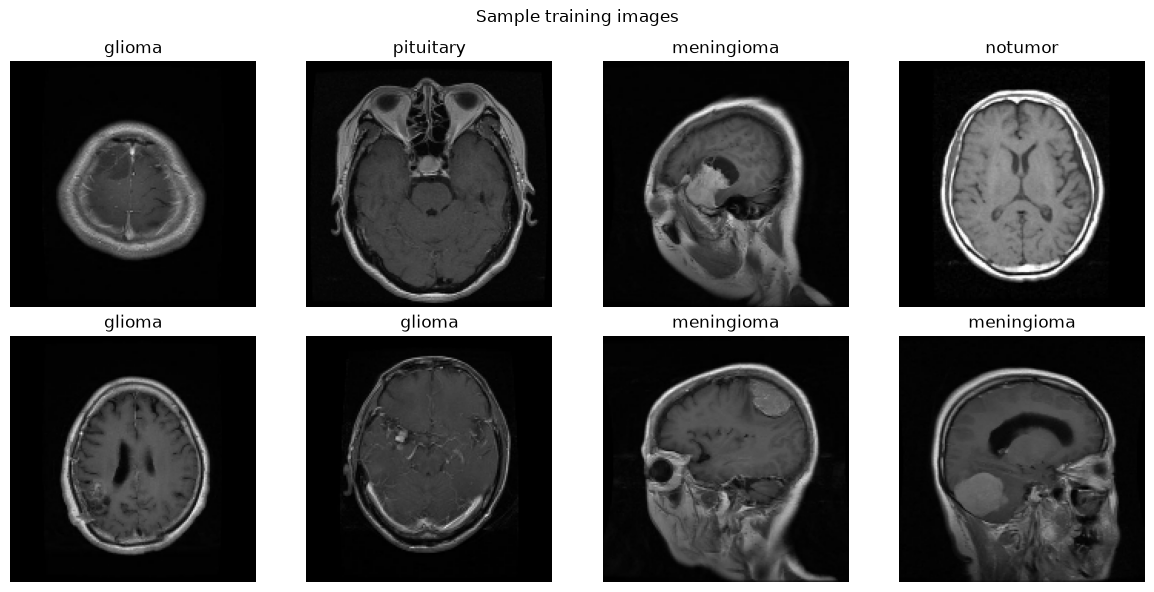

In [54]:

# =========================================================================
# CELL 4 — Visualize a few sample images
# =========================================================================
# What this does:
# Sanity check before training. If labels/images look wrong here, fix it
# now rather than discover it after a full training run. Also useful for
# your report's "Dataset" section — examiners like seeing this.
from PIL import Image
sample_imgs, sample_labels = next(iter(train_data))
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_imgs[i].numpy().astype("uint8"))
    label_idx = np.argmax(sample_labels[i])
    plt.title(class_names[label_idx])
    plt.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "sample_training_images.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()



In [29]:
import sys
print(sys.executable)

/home/sami/tf-gpu-env/bin/python3


In [30]:

# =========================================================================
# CELL 5 — Build the model: EfficientNetB0 transfer learning
# =========================================================================
# What this does:
# We load EfficientNetB0 pretrained on ImageNet (1.4M general photos).
# Even though MRI scans look nothing like ImageNet photos, the EARLY
# layers of any CNN learn generic features (edges, textures, gradients)
# that transfer reasonably well. We freeze those layers (trainable=False)
# so we don't destroy that pretrained knowledge, and we only train a new,
# small classification head on top, specific to our 4 tumor classes.
#
# Why EfficientNetB0 specifically (have this ready for your oral exam):
# - It's far smaller than ResNet50/VGG16 but achieves comparable or
#   better accuracy, because it scales depth/width/resolution together
#   in a balanced way (compound scaling) rather than just stacking more
#   layers blindly.
# - This matters practically: faster training on a single consumer GPU,
#   which is what most of us have.

base_model = EfficientNetB0(
    include_top=False,        # exclude ImageNet's original 1000-class head
    weights="imagenet",
    input_shape=(160, 160, 3)
)
base_model.trainable = False  # freeze pretrained layers for now

x = GlobalAveragePooling2D()(base_model.output)  # collapse feature maps to a vector
x = Dropout(0.3)(x)                               # randomly drop 30% of connections -> reduces overfitting
x = Dense(128, activation="relu")(x)              # learn task-specific combinations
output = Dense(4, activation="softmax")(x)        # 4 probabilities, one per class

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()



Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 160, 160,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 160, 160,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 160, 160,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 161, 161,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 80, 80,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 80, 80,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 80, 80,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 80, 80,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 80, 80,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 80, 80,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 80, 80,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 80, 80,    │        512 │ block1a_se_excit

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [31]:
import tensorflow as tf

print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [59]:

# =========================================================================
# CELL 6 — Train the model
# =========================================================================
# What this does:
# EarlyStopping: stops training automatically if validation loss stops
# improving for 3 epochs in a row, and restores the BEST weights seen —
# not the weights from the last epoch. This directly prevents overfitting,
# which is the single most common reason student projects get criticized.
#
# ReduceLROnPlateau: if validation loss plateaus, automatically lowers the
# learning rate so the model can fine-tune more precisely instead of
# overshooting.

early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)




Epoch 1/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9849 - loss: 0.0453 - val_accuracy: 0.9690 - val_loss: 0.1203 - learning_rate: 3.1250e-05
Epoch 2/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9859 - loss: 0.0438 - val_accuracy: 0.9667 - val_loss: 0.1219 - learning_rate: 3.1250e-05
Epoch 3/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9866 - loss: 0.0412 - val_accuracy: 0.9667 - val_loss: 0.1232 - learning_rate: 3.1250e-05
Epoch 4/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9859 - loss: 0.0448 - val_accuracy: 0.9679 - val_loss: 0.1234 - learning_rate: 1.5625e-05


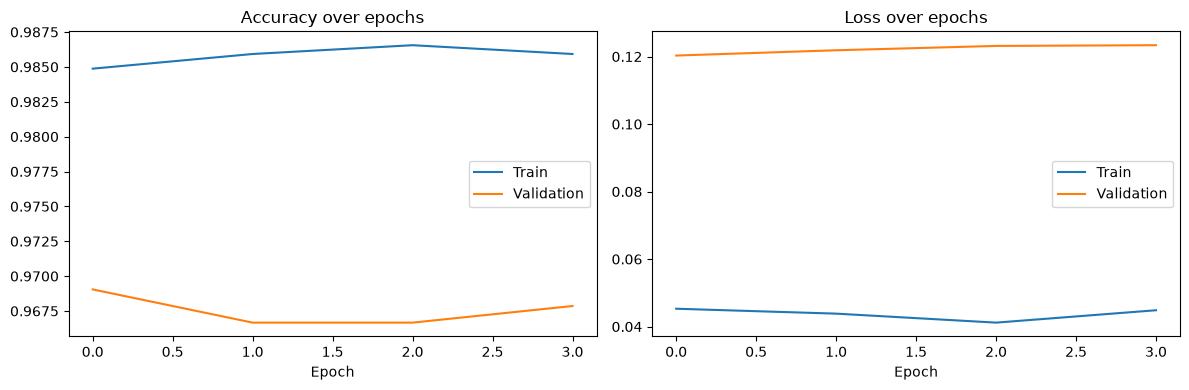

In [61]:

# =========================================================================
# CELL 7 — Plot training curves
# =========================================================================
# What this does:
# Visualizes accuracy/loss across epochs for both training and validation
# sets. A healthy training run shows both curves improving together. If
# training accuracy keeps rising while validation accuracy flattens or
# drops, that's visual proof of overfitting — important to show in your
# report either way, since it demonstrates you checked for it.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png",
            dpi=300,
            bbox_inches="tight")
plt.show()



In [62]:
# =========================================================================
# CELL 8 — Evaluate on the held-out test set
# =========================================================================
# What this does:
# This is the FIRST and ONLY time we touch the Testing folder. Test
# accuracy is the number that actually matters — training/validation
# accuracy can be misleading, since the model has seen that data
# (directly or via tuning decisions) during training.

test_loss, test_acc = model.evaluate(test_data)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9262 - loss: 0.4220

Final Test Accuracy: 0.9262
Final Test Loss: 0.4220


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

      glioma       0.96      0.75      0.85       400
  meningioma       0.85      0.95      0.90       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.96      1.00      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.92      1600
weighted avg       0.93      0.93      0.92      1600



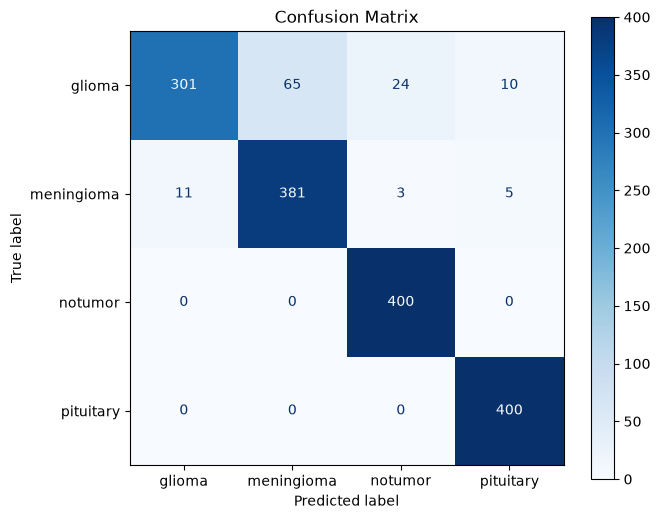

In [63]:

# =========================================================================
# CELL 9 — Confusion matrix and per-class report
# =========================================================================
# What this does:
# Accuracy alone hides WHICH classes the model struggles with. The
# confusion matrix shows exactly which true class gets predicted as which
# wrong class, and classification_report gives precision/recall/F1 per
# class — critical in medical contexts, because missing a real tumor
# (false negative) is far worse than a false alarm (false positive), and
# overall accuracy doesn't distinguish between those error types.
# =========================================================================
# CELL 9 — Confusion matrix and per-class report
# =========================================================================
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

# Extract true labels by iterating the dataset (no .classes attribute
# on tf.data.Dataset, unlike the older ImageDataGenerator)
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_data])

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix")
plt.savefig(OUTPUT_DIR / "confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [64]:


# =========================================================================
# CELL 10 — Grad-CAM implementation
# =========================================================================
# What this does (THIS IS YOUR PROJECT'S DIFFERENTIATOR):
# Grad-CAM (Gradient-weighted Class Activation Mapping) answers a
# question accuracy numbers can NEVER answer: "WHERE in the image did
# the model look to make this decision?"
#
# How it works, briefly:
# 1. We look at the output of the model's last convolutional layer
#    (a 3D grid of learned features, before final pooling/classification).
# 2. We compute the gradient of the predicted class score with respect to
#    that feature map — this tells us which feature-map regions most
#    influenced the prediction.
# 3. We weight the feature map by those gradients and average it into a
#    single 2D heatmap, then upscale it to overlay on the original image.
#
# Why this matters for medical AI specifically: a model can reach 95%
# accuracy while actually focusing on irrelevant artifacts (image
# borders, scanner markings) rather than the tumor itself — this is a
# well-documented failure mode in medical imaging literature. Grad-CAM is
# how you check for that, and is exactly the kind of analysis that
# distinguishes a research-minded project from a tutorial copy.

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)               # how much each feature matters
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))     # average importance per channel
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]   # weighted combination
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)  # normalize 0-1
    return heatmap.numpy(), class_idx.numpy()


def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlayed = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    return overlayed





In [65]:

# =========================================================================
# CELL 11 — Find the correct last conv layer name (run this if Cell 12 errors)
# =========================================================================
# What this does:
# Grad-CAM needs the EXACT name of the last convolutional layer, and this
# can vary slightly between TensorFlow/Keras versions. Run this once,
# look at the last few printed layer names, and find the one that sounds
# like a final conv block (commonly "top_conv" in EfficientNetB0).

for layer in model.layers[-10:]:
    print(layer.name, "-", layer.__class__.__name__)


block7a_se_excite - Multiply
block7a_project_conv - Conv2D
block7a_project_bn - BatchNormalization
top_conv - Conv2D
top_bn - BatchNormalization
top_activation - Activation
global_average_pooling2d_1 - GlobalAveragePooling2D
dropout_1 - Dropout
dense_2 - Dense
dense_3 - Dense


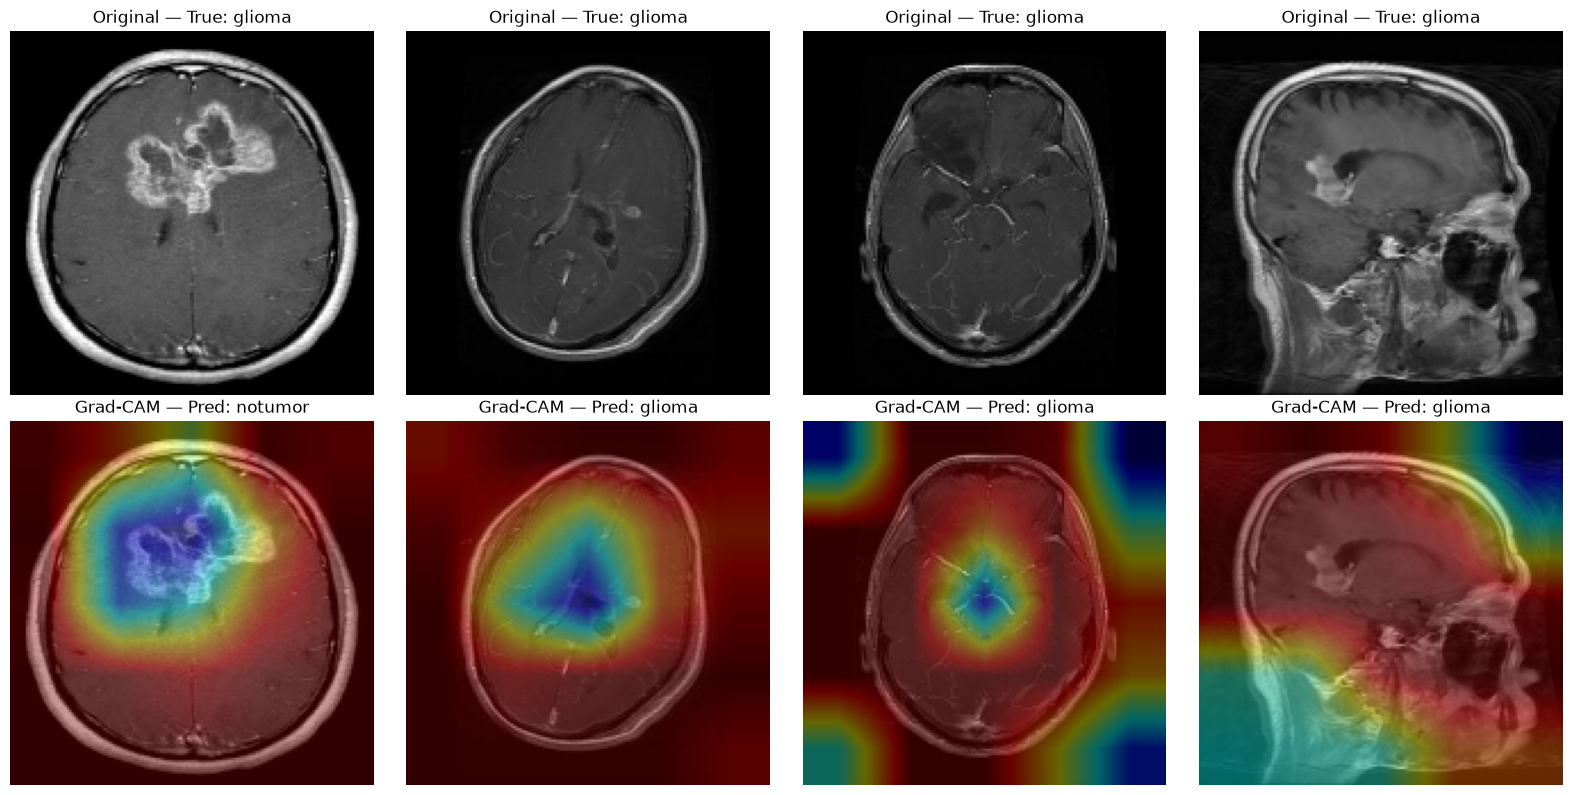

In [67]:
# =========================================================================
# CELL 12 — Run Grad-CAM on sample test images
# =========================================================================
# What this does:
# Picks a batch of test images, runs Grad-CAM on each, and displays the
# original image next to its heatmap overlay. Look specifically at
# whether the highlighted (red/yellow) region lines up with the actual
# tumor location for glioma/meningioma/pituitary images.
#
# BUG FIX vs. the previous version of this cell:
# `next(test_data)` raised:
#   TypeError: '_PrefetchDataset' object is not an iterator
# This happened because test_data is built with
# tf.keras.utils.image_dataset_from_directory (Cell 3), which returns a
# tf.data.Dataset (a _PrefetchDataset under the hood) — NOT a Keras
# DirectoryIterator. next() only works directly on the older
# DirectoryIterator/ImageDataGenerator type. A tf.data.Dataset must
# either be wrapped in iter() first, or looped over with a for-loop.
#
# FIX: pull one batch with `next(iter(test_data))` instead of
# `next(test_data)`. Also note this dataset was NOT manually rescaled
# (see Cell 3's comment — EfficientNetB0 expects raw 0-255 pixels), so
# images here are already in the right range for the model and don't
# need the *255 conversion the original code used.

LAST_CONV_LAYER = "top_conv"  # change this if Cell 11 showed a different name

sample_batch, sample_labels = next(iter(test_data))
sample_batch = sample_batch.numpy()
sample_labels = sample_labels.numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img_array = np.expand_dims(sample_batch[i], axis=0)
    heatmap, pred_class = get_gradcam_heatmap(model, img_array, LAST_CONV_LAYER)

    # sample_batch is already 0-255 (no rescale layer in this version of
    # Cell 3), so just cast to uint8 for display — no *255 needed here.
    original_img = np.uint8(sample_batch[i])
    overlayed = overlay_heatmap(original_img, heatmap)

    true_class = class_names[np.argmax(sample_labels[i])]
    pred_label = class_names[pred_class]

    axes[0, i].imshow(original_img)
    axes[0, i].set_title(f"Original — True: {true_class}")
    axes[0, i].axis("off")

    axes[1, i].imshow(overlayed)
    axes[1, i].set_title(f"Grad-CAM — Pred: {pred_label}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "gradcam_results.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Total misclassified: 118 out of 1600 test images

Most common confusion pairs (true -> predicted):
  glioma -> meningioma: 65 times
  glioma -> notumor: 24 times
  meningioma -> glioma: 11 times
  glioma -> pituitary: 10 times
  meningioma -> pituitary: 5 times


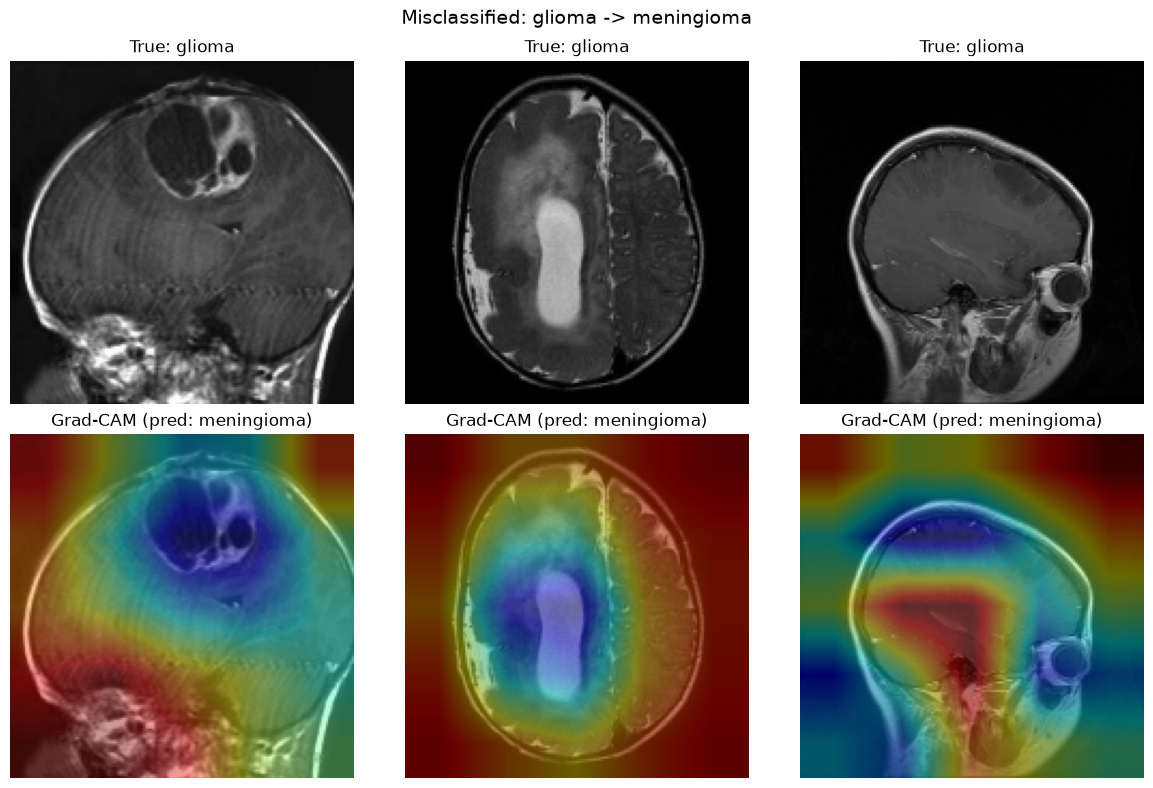

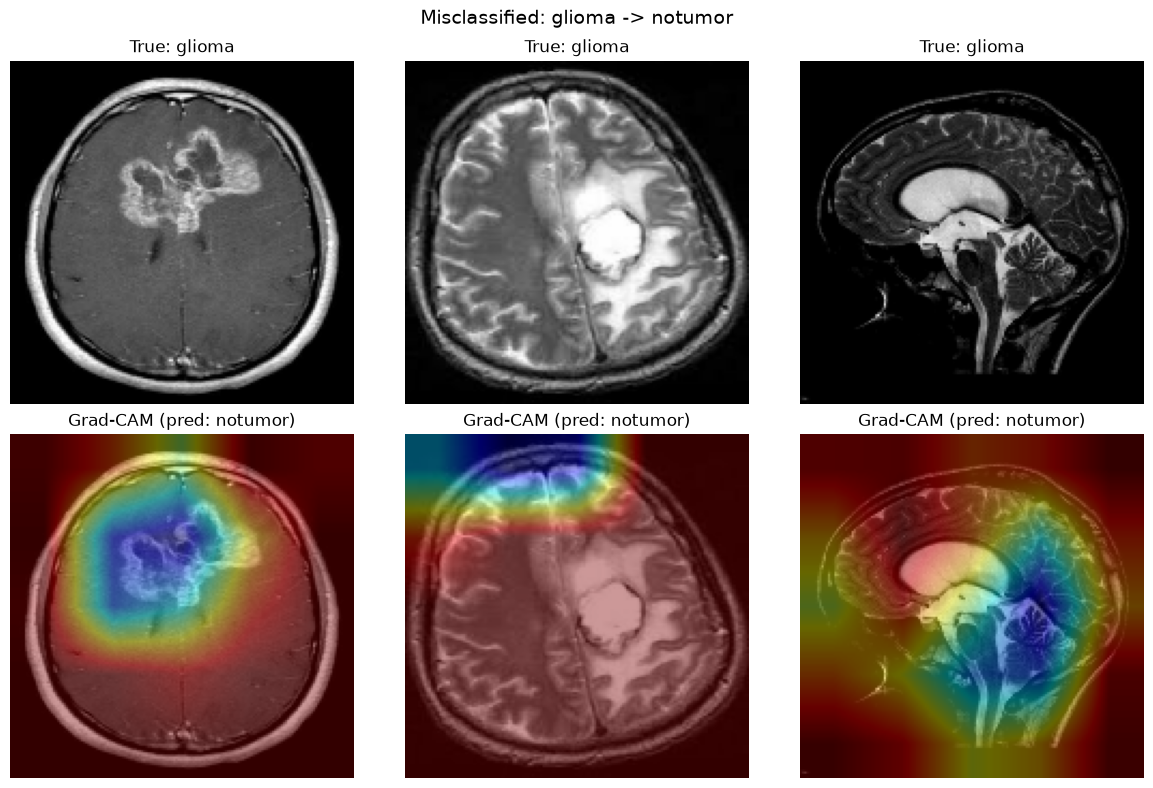

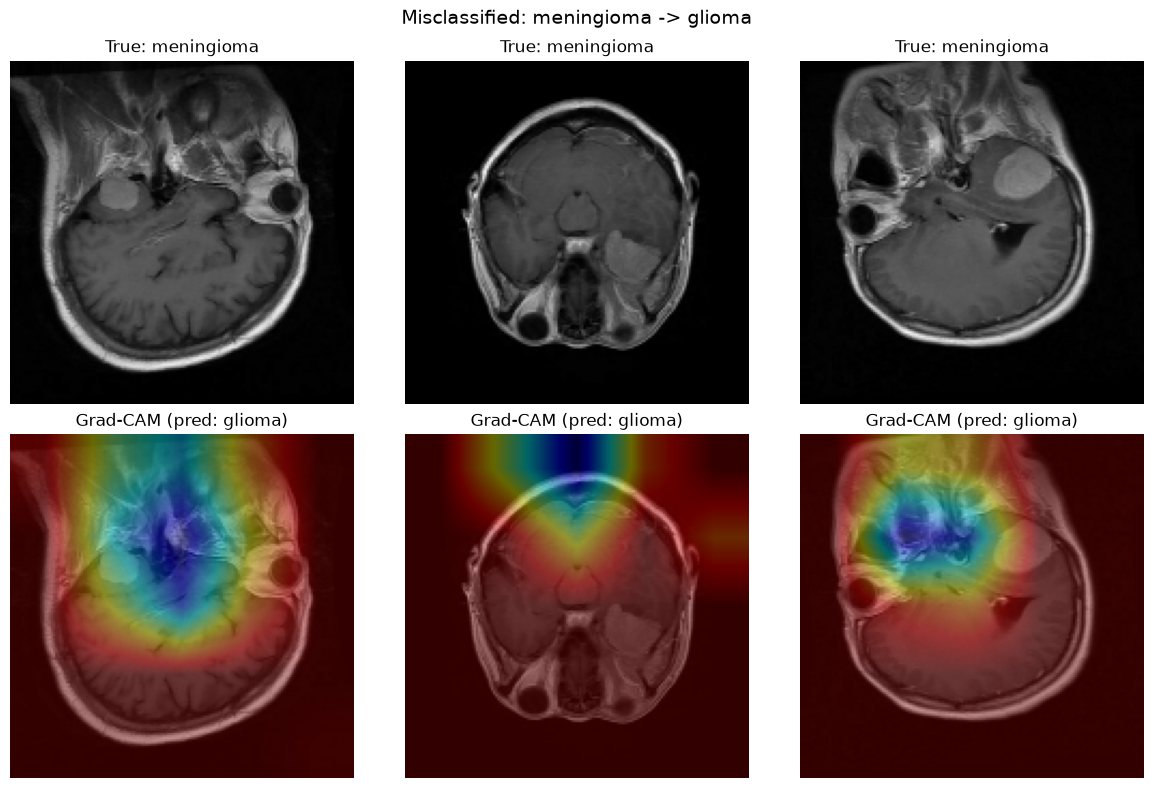

In [70]:


# =========================================================================
# CELL 13 — Misclassification deep-dive (Objectives 3 & 4)
# =========================================================================
# What this does:
# This cell delivers Objective 3 ("identify whether the model focuses on
# the tumor or on irrelevant artifacts") and Objective 4 ("systematic
# misclassification analysis... examine their Grad-CAM heatmaps for an
# explanation") by running Grad-CAM specifically on confirmed wrong
# predictions, grouped by the most common confusion pairs.
#
# BUG FIX vs. the previous version of this cell:
# `test_data.filenames` raised:
#   AttributeError: '_PrefetchDataset' object has no attribute 'filenames'
# Same root cause as Cell 12: test_data is a tf.data.Dataset (from
# image_dataset_from_directory), which does not track source file paths
# at all — there is no .filenames or .filepaths equivalent.
#
# FIX: instead of reloading images from disk by path, collect the actual
# image arrays directly from test_data while iterating it — the same
# approach Cell 9 already uses to collect y_true from the labels. This
# avoids needing file paths entirely. Images are collected once here in
# the same order as y_true/y_pred (test_data has shuffle=False, set in
# Cell 3), so indexing with wrong_idx lines up correctly.

# =========================================================================
# MISCLASSIFIED INDICES
# =========================================================================
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} out of {len(y_true)} test images\n")

from collections import Counter
confusion_pairs = Counter()
for i in wrong_idx:
    pair = (class_names[y_true[i]], class_names[y_pred[i]])
    confusion_pairs[pair] += 1

print("Most common confusion pairs (true -> predicted):")
for pair, count in confusion_pairs.most_common(5):
    print(f"  {pair[0]} -> {pair[1]}: {count} times")

# --- Collect all test images into one array, same order as y_true/y_pred ---
# (No filepaths exist for this dataset type, so we use the actual pixel
# arrays already flowing through test_data instead of reloading from disk.)
all_test_images = np.concatenate([images.numpy() for images, _ in test_data], axis=0)

# --- Objective 3 & 4: Grad-CAM on the actual misclassified images ---
top_pairs = [pair for pair, _ in confusion_pairs.most_common(3)]

for true_cls, pred_cls in top_pairs:
    example_idx = [
        i for i in wrong_idx
        if class_names[y_true[i]] == true_cls and class_names[y_pred[i]] == pred_cls
    ][:3]

    if not example_idx:
        continue

    fig, axes = plt.subplots(2, len(example_idx), figsize=(4 * len(example_idx), 8))
    if len(example_idx) == 1:
        axes = axes.reshape(2, 1)

    for col, idx in enumerate(example_idx):
        img = all_test_images[idx]                  # already 0-255, matches Cell 3
        img_array = np.expand_dims(img, axis=0)

        heatmap, _ = get_gradcam_heatmap(model, img_array, LAST_CONV_LAYER)
        overlayed = overlay_heatmap(np.uint8(img), heatmap)

        axes[0, col].imshow(np.uint8(img))
        axes[0, col].set_title(f"True: {true_cls}")
        axes[0, col].axis("off")

        axes[1, col].imshow(overlayed)
        axes[1, col].set_title(f"Grad-CAM (pred: {pred_cls})")
        axes[1, col].axis("off")

    plt.suptitle(f"Misclassified: {true_cls} -> {pred_cls}", fontsize=14)
    plt.tight_layout()
    plt.savefig(
    OUTPUT_DIR / "misclassified_samples.png",
    dpi=300,
    bbox_inches="tight")
    plt.show()

# --- Write your interpretation here after running the cell ---
# This is what completes Objective 3 in substance, not just in code:
# look at the heatmaps above and answer concretely —
# - Is the highlighted region inside the brain, near where a tumor would
#   actually be?
# - Or is it on borders, skull edges, scan corners, or scanner artifacts?
# - Does the pattern differ between correct predictions (Cell 12) and
#   these misclassified ones?
# Your answer — based on YOUR actual run, not a guess — is the real
# content of Objective 3 and your oral exam defense.

In [44]:
# =========================================================================
# CELL 14 — Save the trained model
# =========================================================================
# What this does:
# Saves the trained model to disk so you don't need to retrain every
# time you reopen the notebook. The .keras format is the current
# standard recommended by Keras (replaces the older .h5 format).

model.save("brain_tumor_efficientnetb0.keras")
print("Model saved as brain_tumor_efficientnetb0.keras")

Model saved as brain_tumor_efficientnetb0.keras
